# Grover's Algorithm

This is the specific grover's algorithm with assumption of only one unique search so we have defined requir

## improting libraries

In [1]:
import sys
import numpy as np
from qiskit import QuantumCircuit,  transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import math


following section is useful only if you are not running in notebook 

In [3]:
"""if len(sys.argv) > 1:
    n = int(sys.argv[1])
    target = str(sys.argv[2])
    shots = int(sys.argv[3]) if len(sys.argv) > 3 else 1024
else:
    n = 4  # default number of qubits
    target = "1011"  # default target state
    shots = 1024  # default number of shots
"""

'if len(sys.argv) > 1:\n    n = int(sys.argv[1])\n    target = str(sys.argv[2])\n    shots = int(sys.argv[3]) if len(sys.argv) > 3 else 1024\nelse:\n    n = 4  # default number of qubits\n    target = "1011"  # default target state\n    shots = 1024  # default number of shots\n'

### Configure the number of qubits, target and no. of shots

In [4]:
n = 4  
target = "1011"  
shots = 1024  

print(f"Number of qubits: {n}, Target state: {target}, Shots: {shots}")

Number of qubits: 4, Target state: 1011, Shots: 1024


## Main diffuser $(-U_0)$
that only gives - sign to the state $|0..0\rangle$

In [5]:
def U_0(qc: QuantumCircuit, n):
    """Diffusion operator that gives -1 phase to |00...0> state"""
    qc.barrier()
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.barrier()
    return qc

### Oracle 
This is to mark the target 

In [6]:
def U_f(qc: QuantumCircuit, n, target):
    """main oracle that flips the sign of the target state"""
    qc.barrier()
    
    # flip as per target
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)
    
    # H-CNOT-H
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    # Unflip qubits
    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)
    
    qc.barrier()
    return qc

## Complete composed circuit


In [7]:
def net_circuit(n, target):
    # Main Circuit 
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    
    #iter
    t = round((math.pi / 4) * math.sqrt(2**n))
    print("we got t= ",t)
                                    
    
    for _ in range(t):
        qc = U_f(qc, n, target)
        qc.h(range(n))
        qc = U_0(qc, n)
        qc.h(range(n))
    
    # measure
    qc.measure(range(n), range(n))
    return qc


we got t=  3


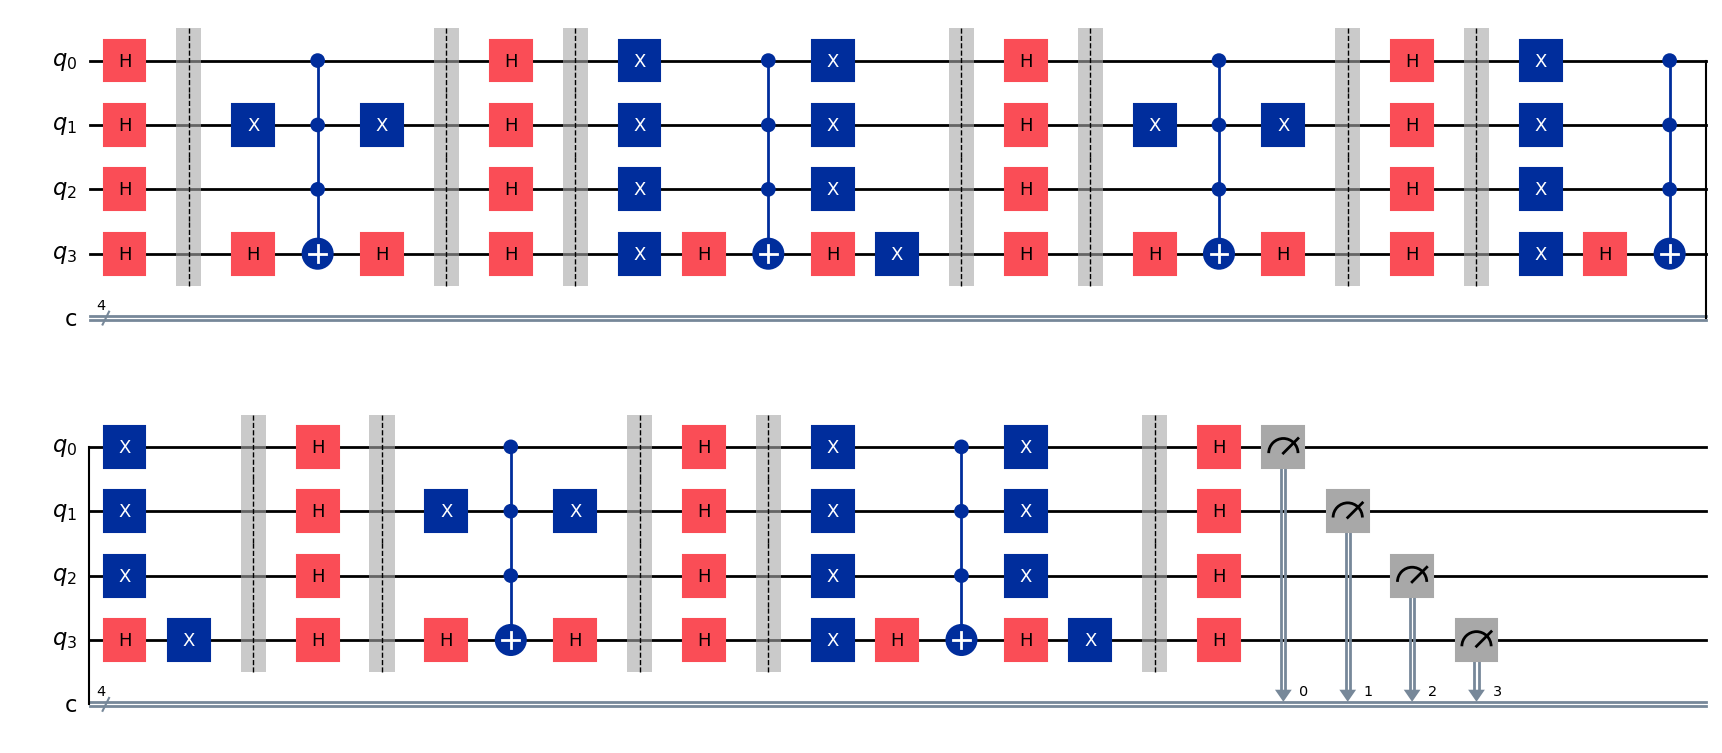

In [8]:
# Test the circuit
QC = net_circuit(n, target)

QC.draw("mpl")
# plt.show()


{'0001': 5, '1101': 965, '1100': 9, '0110': 5, '1000': 2, '1011': 2, '0011': 3, '0111': 7, '0000': 4, '0010': 2, '1010': 2, '1001': 6, '0101': 7, '0100': 3, '1111': 2}


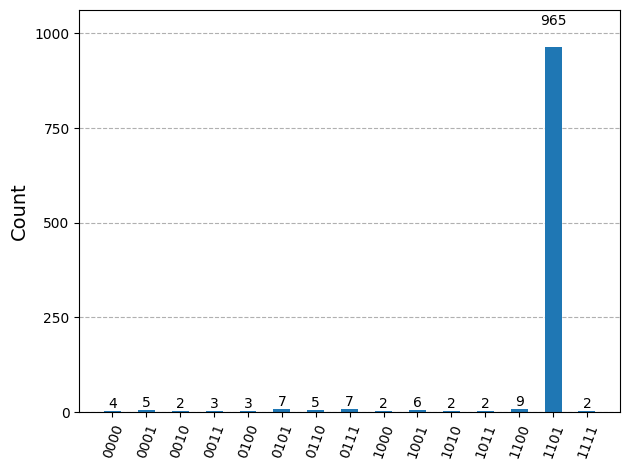

In [9]:
simulator = AerSimulator()
compiled_circuit = transpile(QC, simulator)
result = simulator.run(compiled_circuit, shots=shots).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
# plt.show()